# Separating A and E$_a$: multi-temperature fitting with analytic Jacobians

At a single temperature only the rate constant $k(T) = A\,e^{-E_a/RT}$ is identifiable — $A$ and $E_a$ are perfectly correlated (the Arrhenius intercept $\log A$ lives at $1/T=0$, far from the data). **Multiple temperatures** break that degeneracy. We fit a JAX forward model with POUNCE's `curve_fit` using `jac='jax'`, so it detects the model and uses the **analytic** Jacobian (exact covariance).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
%matplotlib inline

## A JAX, jit-able forward model (RK4) parameterized by a single vector

We parametrize by $\log_{10} k_{\mathrm{ref}}$ (the surface rate constant at a reference temperature) and $E_a$ — a centered parametrization that is far better conditioned than $(\log A, E_a)$. The model is written in `jax.numpy` with a fixed-step RK4 so `curve_fit` can trace and differentiate it.

In [2]:
import numpy as np, jax, jax.numpy as jnp
jax.config.update('jax_enable_x64', True)
import pounce

def rk4(f, y0, ts):
    def step(y, tp):
        t0, t1 = tp; h = t1 - t0
        k1 = f(y, t0); k2 = f(y + h/2*k1, t0+h/2); k3 = f(y + h/2*k2, t0+h/2); k4 = f(y + h*k3, t1)
        yn = y + h/6*(k1 + 2*k2 + 2*k3 + k4); return yn, yn
    pairs = jnp.stack([ts[:-1], ts[1:]], 1); _, ys = jax.lax.scan(step, y0, pairs)
    return jnp.vstack([y0[None], ys])

R, Tref, A_ads, A_O2, Pco, Po2 = 8.617e-5, 500.0, 100.0, 100.0, 1.0, 0.5
fine = jnp.linspace(0, 0.6, 80); keep = np.linspace(0, 79, 20).astype(int)

def rco2(T, theta):                      # theta = [log10 k_ref, Ea]
    def rhs(y, t):
        kf3 = (10**theta[0]) * jnp.exp(-theta[1]/R * (1/T - 1/Tref))
        c, o = y[0], y[1]; fr = 1 - c - o
        return jnp.array([A_ads*(Pco*fr - c) - kf3*c*o, 2*A_O2*(Po2*fr**2 - o**2) - kf3*c*o])
    Y = rk4(rhs, jnp.array([0.0, 0.0]), fine)[keep]
    kf3 = (10**theta[0]) * jnp.exp(-theta[1]/R * (1/T - 1/Tref))
    return kf3 * Y[:, 0] * Y[:, 1]

k_ref_true = 1e8*np.exp(-0.7/(R*Tref)); theta_true = jnp.array([np.log10(k_ref_true), 0.7])
print(f'true: k_ref = {k_ref_true:.3g}  (=> A = 1e8),  Ea = 0.7')

true: k_ref = 8.79  (=> A = 1e8),  Ea = 0.7


## Single temperature: E$_a$ is undetermined

At $T = T_{ref}$ the response does not depend on $E_a$ at all (its sensitivity is zero), so $E_a$ cannot be recovered — only $k_{ref}$.

In [3]:
sim1 = lambda th: rco2(500.0, th)
J1 = np.asarray(jax.jacobian(sim1)(theta_true))
print('sensitivity column norms at T=500:  d/d log k_ref = %.3g,  d/d Ea = %.3g'
      % (np.linalg.norm(J1[:,0]), np.linalg.norm(J1[:,1])))
print('-> the Ea column is ~0, so Ea is undetermined from single-temperature data')

sensitivity column norms at T=500:  d/d log k_ref = 8.15,  d/d Ea = 0
-> the Ea column is ~0, so Ea is undetermined from single-temperature data


## Three temperatures: fit with POUNCE `curve_fit` (analytic Jacobian)

In [4]:
Ts = [440.0, 500.0, 560.0]
sim = lambda th: jnp.concatenate([rco2(T, th) for T in Ts])
rng = np.random.default_rng(0)
data = np.array(sim(theta_true)); data = data + rng.normal(0, 0.02*data.std(), data.shape)

res = pounce.curve_fit(lambda x, logk, Ea: sim(jnp.array([logk, Ea])),
                       np.arange(len(data)), data, p0=[0.5, 0.4], jac='jax')
A_fit = 10**res.popt[0] * np.exp(res.popt[1]/(R*Tref))
print(f'fitted : k_ref = {10**res.popt[0]:.3g},  Ea = {res.popt[1]:.4f}  =>  A = {A_fit:.3g}')
print(f'covariance source: {res.cov_source}  (analytic JAX Jacobian)')
print(f'95% CIs (log k_ref, Ea): {np.round(np.asarray(res.ci), 3).tolist()}')
print(f'parameter correlation: {np.asarray(res.correlation)[0,1]:+.3f}')

fitted : k_ref = 8.8,  Ea = 0.7012  =>  A = 1.03e+08
covariance source: reduced_hessian  (analytic JAX Jacobian)
95% CIs (log k_ref, Ea): [[0.937, 0.952], [0.694, 0.709]]
parameter correlation: -0.977


## Plot the data and the fits

The fitted model (lines) through the noisy multi-temperature data (points). Because each temperature has its own transient, the three curves together constrain both the rate constant and its temperature dependence.

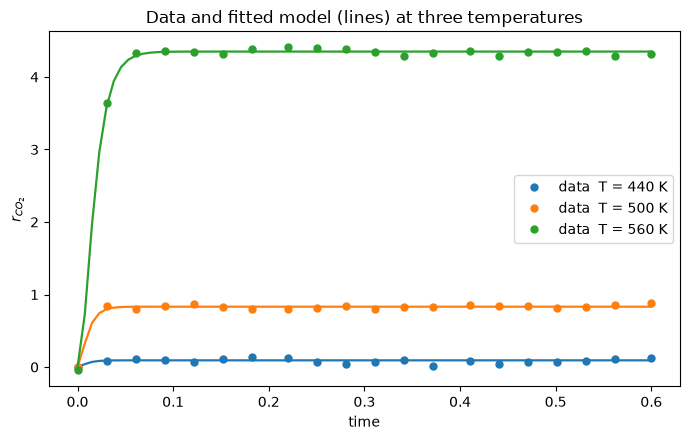

In [5]:
import matplotlib.pyplot as plt
t_meas = np.asarray(fine)[keep]
tfine = np.asarray(fine)
colors = ['C0', 'C1', 'C2']

def curve(T, theta):
    """Dense CO2-rate trajectory at temperature T for plotting."""
    def rhs(y, t):
        kf3 = (10**theta[0]) * jnp.exp(-theta[1]/R * (1/T - 1/Tref))
        c, o = y[0], y[1]; fr = 1 - c - o
        return jnp.array([A_ads*(Pco*fr - c) - kf3*c*o, 2*A_O2*(Po2*fr**2 - o**2) - kf3*c*o])
    Y = rk4(rhs, jnp.array([0.0, 0.0]), fine)
    kf3 = (10**theta[0]) * jnp.exp(-theta[1]/R * (1/T - 1/Tref))
    return np.asarray(kf3 * Y[:, 0] * Y[:, 1])

fig, ax = plt.subplots(figsize=(7, 4.5))
n = len(keep)
for i, T in enumerate(Ts):
    d = data[i*n:(i+1)*n]
    ax.plot(t_meas, d, 'o', color=colors[i], ms=5, label=f'data  T = {T:.0f} K')
    ax.plot(tfine, curve(T, res.popt), '-', color=colors[i], lw=1.6)
ax.set_xlabel('time'); ax.set_ylabel(r'$r_{CO_2}$')
ax.set_title('Data and fitted model (lines) at three temperatures')
ax.legend(); fig.tight_layout()


An Arrhenius view makes the identifiability explicit: the surface rate constant $k(T) = A\,e^{-E_a/RT}$ is a line in $\ln k$ vs $1/T$ whose **slope is $-E_a/R$**. A single temperature fixes one point on this line (any slope fits); the spread of temperatures pins the slope, so $E_a$ (and hence $A$) is recovered. The fitted line sits on the true one.

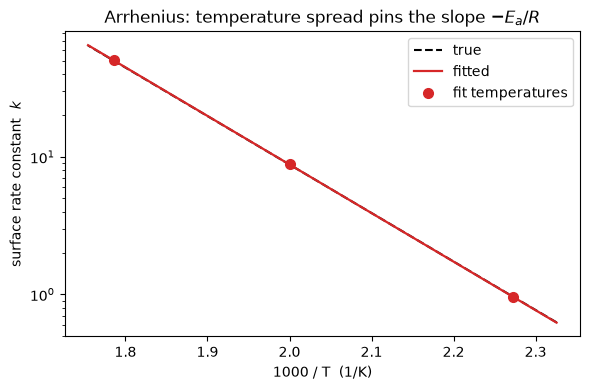

In [6]:
Tgrid = np.linspace(430, 570, 60)
kf = lambda th, T: (10**th[0]) * np.exp(-th[1]/R * (1/T - 1/Tref))
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(1000/Tgrid, kf(np.asarray(theta_true), Tgrid), 'k--', label='true')
ax.semilogy(1000/Tgrid, kf(res.popt, Tgrid), 'C3', lw=1.6, label='fitted')
ax.semilogy(1000/np.array(Ts), [kf(res.popt, T) for T in Ts], 'C3o', ms=7, label='fit temperatures')
ax.set_xlabel('1000 / T  (1/K)'); ax.set_ylabel('surface rate constant  $k$')
ax.set_title(r'Arrhenius: temperature spread pins the slope $-E_a/R$')
ax.legend(); fig.tight_layout()


## Takeaways

- A **single param-vector JAX model** (here a jit-able RK4) lets `pounce.curve_fit(jac='jax')` use the **analytic Jacobian** — exact covariance and confidence intervals, no finite differences.
- **Single temperature**: $E_a$ is unidentifiable (its sensitivity is zero at $T_{ref}$); you only get $k(T)$.
- **Multiple temperatures** recover both $k_{ref}$ and $E_a$ (and hence $A$). The centered $(\log k_{ref}, E_a)$ parametrization keeps the problem well conditioned; the raw $(\log A, E_a)$ would be almost perfectly correlated.
- Note: POUNCE's `curve_fit` auto-detect uses **forward-mode** AD and `jit`, so the model must be jit-able and forward-differentiable (a pure-JAX RK4 qualifies; `jax.experimental.ode.odeint` and `pounce.jax.odeint` are reverse-mode only — for those, pass an explicit reverse-mode `jac=`).
- This complements the transient PRBS notebook: PRBS at one temperature pins the dynamic rate constants; a temperature series separates $A$ from $E_a$.